In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [41]:
population = pd.read_csv("../data/population.csv")
pollution  = pd.read_csv("../data/global_air_pollution.csv")


In [82]:
merged.columns = merged.columns.str.replace("\n", " ", regex=False)
merged.columns = merged.columns.str.strip()

In [83]:
population.head(), pollution.head()


(       Country Density\n(P/Km2) Abbreviation Agricultural Land( %)  \
 0  Afghanistan               60           AF                58.10%   
 1      Albania              105           AL                43.10%   
 2      Algeria               18           DZ                17.40%   
 3      Andorra              164           AD                40.00%   
 4       Angola               26           AO                47.50%   
 
   Land Area(Km2) Armed Forces size  Birth Rate  Calling Code  \
 0        652,230           323,000       32.49          93.0   
 1         28,748             9,000       11.78         355.0   
 2      2,381,741           317,000       24.28         213.0   
 3            468               NaN        7.20         376.0   
 4      1,246,700           117,000       40.73         244.0   
 
   Capital/Major City Co2-Emissions  ... Out of pocket health expenditure  \
 0              Kabul         8,672  ...                           78.40%   
 1             Tirana     

In [84]:
population.info()
pollution.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    object 
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    object 
 4   Land Area(Km2)                             194 non-null    object 
 5   Armed Forces size                          171 non-null    object 
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    object 
 10  CPI                       

In [85]:
population.columns = population.columns.str.replace("\n", " ")
population.columns


Index(['Country', 'Density (P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='object')

In [86]:
#  Cleaning Function (Code cell)
pop = population.copy()

def clean_numeric(col):
    return (
        col.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
    )

cols_to_clean = [
    "Density (P/Km2)",
    "Agricultural Land( %)",
    "Land Area(Km2)",
    "Co2-Emissions",
    "GDP",
    "Population"
]

for col in cols_to_clean:
    pop[col] = pd.to_numeric(clean_numeric(pop[col]), errors="coerce")


In [87]:
pop.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density (P/Km2)                            195 non-null    int64  
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    float64
 4   Land Area(Km2)                             194 non-null    float64
 5   Armed Forces size                          171 non-null    object 
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    float64
 10  CPI                       

In [88]:
pop.describe()


,Density (P/Km2),Agricultural Land( %),Land Area(Km2),Birth Rate,Calling Code,Co2-Emissions,Fertility Rate,GDP,Infant mortality,Life expectancy,Maternal mortality ratio,Physicians per thousand,Population,Latitude,Longitude
count,195.000000,188.000000,1.940000e+02,189.000000,194.000000,1.880000e+02,188.000000,0.0,189.000000,187.000000,181.000000,188.000000,1.940000e+02,194.000000,194.000000
mean,356.764103,39.117553,6.896244e+05,20.214974,360.546392,1.777992e+05,2.698138,NaN,21.332804,72.279679,160.392265,1.839840,3.938116e+07,19.092351,20.232434
std,1982.888967,21.783052,1.921609e+06,9.945774,323.236419,8.387903e+05,1.282267,NaN,19.548058,7.483661,233.502024,1.684261,1.450924e+08,23.961779,66.716110
min,2.000000,0.600000,0.000000e+00,5.900000,1.000000,1.100000e+01,0.980000,NaN,1.400000,52.800000,2.000000,0.010000,8.360000e+02,-40.900557,-175.198242
25%,35.500000,21.700000,2.382825e+04,11.300000,82.500000,2.304250e+03,1.705000,NaN,6.000000,67.000000,13.000000,0.332500,1.962678e+06,4.544175,-7.941496
50%,89.000000,39.600000,1.195110e+05,17.950000,255.500000,1.230300e+04,2.245000,NaN,14.000000,73.200000,53.000000,1.460000,8.826588e+06,17.273849,20.972652
75%,216.500000,55.375000,5.242560e+05,28.750000,506.750000,6.388425e+04,3.597500,NaN,32.700000,77.500000,186.000000,2.935000,2.858549e+07,40.124603,48.281523
max,26337.000000,82.600000,1.709824e+07,46.080000,1876.000000,9.893038e+06,6.910000,NaN,84.500000,85.400000,1150.000000,8.420000,1.397715e+09,64.963051,178.065032


In [89]:
pollution.describe()


,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


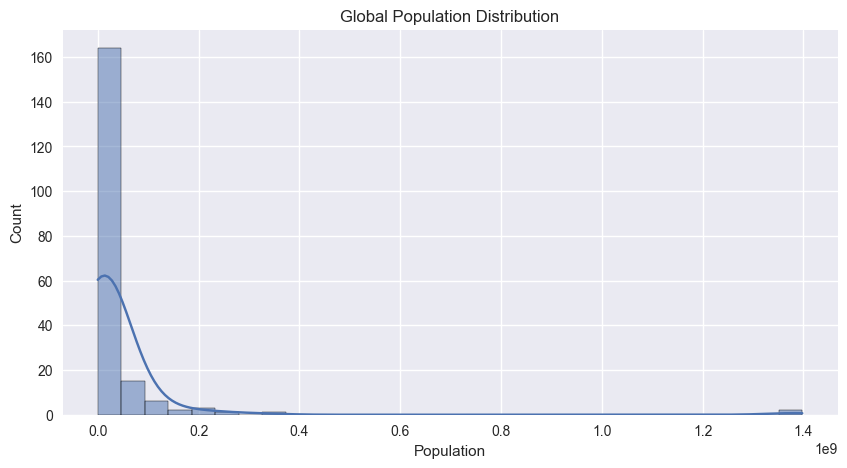

In [90]:
# First EDA Visuals
plt.figure(figsize=(10,5))
sns.histplot(pop["Population"], bins=30, kde=True)
plt.title("Global Population Distribution")
plt.show()


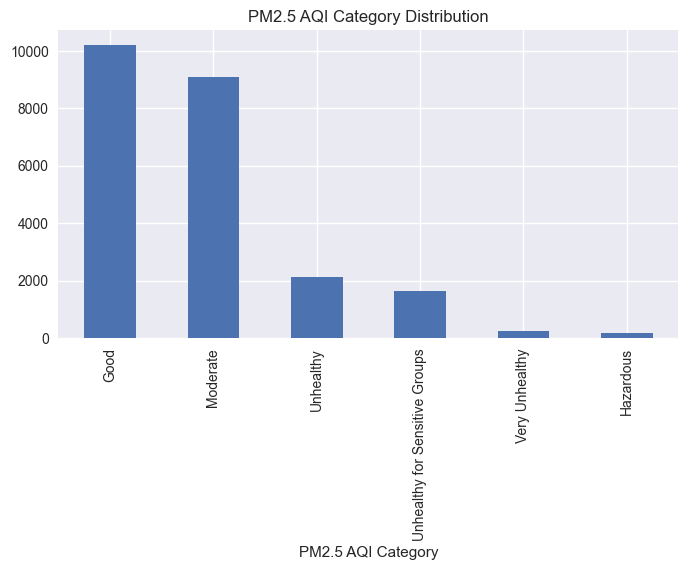

In [91]:
# AQI Category Distribution
pollution["PM2.5 AQI Category"].value_counts().plot(
    kind="bar", figsize=(8,4), title="PM2.5 AQI Category Distribution"
)

plt.show()

## 🔍 Initial Insights
- Population is heavily skewed toward a few highly populated countries
- Majority of AQI values fall into moderate to unhealthy categories
- Environmental stress is unevenly distributed across regions


## 🌫️ Pollution Severity by Country
Analyzing which countries experience the highest air pollution based on PM2.5 AQI values.


In [92]:
pollution.columns = pollution.columns.str.strip()
pollution.columns


Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category'],
      dtype='object')

In [93]:
country_pollution = (
    pollution.groupby("Country")["PM2.5 AQI Value"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

country_pollution


Country
Republic of Korea       415.000000
Bahrain                 188.000000
Mauritania              179.000000
Pakistan                173.110749
Aruba                   163.000000
Kuwait                  162.000000
United Arab Emirates    152.666667
Senegal                 152.424242
India                   149.463023
Saudi Arabia            149.285714
Qatar                   147.500000
Gambia                  147.000000
Yemen                   144.571429
Guinea-Bissau           138.750000
Oman                    134.833333
Name: PM2.5 AQI Value, dtype: float64

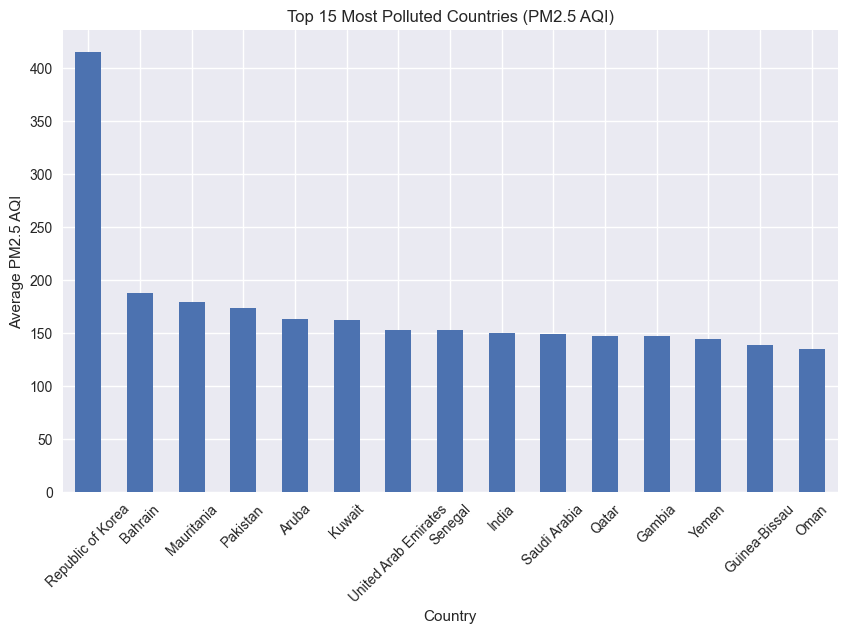

In [94]:
plt.figure(figsize=(10,6))
country_pollution.plot(kind="bar")
plt.title("Top 15 Most Polluted Countries (PM2.5 AQI)")
plt.ylabel("Average PM2.5 AQI")
plt.xticks(rotation=45)
plt.show()


In [95]:
country_pollution = (
    pollution.groupby("Country")["PM2.5 AQI Value"]
    .mean()
    .sort_values(ascending=False)
)

country_pollution_df = country_pollution.reset_index()
country_pollution_df.columns = ["Country", "Avg_PM25_AQI"]

In [96]:
merged = pd.merge(
    pop,
    country_pollution_df,
    on="Country",
    how="inner"
)

merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 36 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    153 non-null    object 
 1   Density (P/Km2)                            153 non-null    int64  
 2   Abbreviation                               152 non-null    object 
 3   Agricultural Land( %)                      151 non-null    float64
 4   Land Area(Km2)                             153 non-null    float64
 5   Armed Forces size                          145 non-null    object 
 6   Birth Rate                                 153 non-null    float64
 7   Calling Code                               153 non-null    float64
 8   Capital/Major City                         151 non-null    object 
 9   Co2-Emissions                              152 non-null    float64
 10  CPI                       

In [97]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 36 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    153 non-null    object 
 1   Density (P/Km2)                            153 non-null    int64  
 2   Abbreviation                               152 non-null    object 
 3   Agricultural Land( %)                      151 non-null    float64
 4   Land Area(Km2)                             153 non-null    float64
 5   Armed Forces size                          145 non-null    object 
 6   Birth Rate                                 153 non-null    float64
 7   Calling Code                               153 non-null    float64
 8   Capital/Major City                         151 non-null    object 
 9   Co2-Emissions                              152 non-null    float64
 10  CPI                       

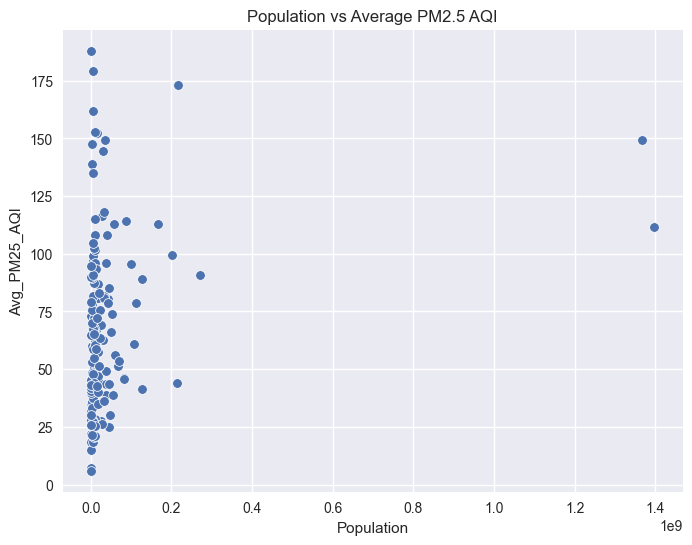

In [98]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged,
    x="Population",
    y="Avg_PM25_AQI"
)

plt.title("Population vs Average PM2.5 AQI")
plt.show()

In [102]:
merged["Population"].dtype

dtype('float64')

In [104]:
merged.columns

Index(['Country', 'Density (P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude', 'Avg_PM25_AQI'],
      dtype='object')

In [106]:
merged.columns = merged.columns.str.replace("\n", " ", regex=False)
merged.columns = merged.columns.str.strip()

In [109]:
merged["Density (P/Km2)"] = (
    merged["Density (P/Km2)"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

merged["Density (P/Km2)"] = pd.to_numeric(
    merged["Density (P/Km2)"],
    errors="coerce"
)

In [110]:
merged[["Population", "Avg_PM25_AQI"]].corr()

,Population,Avg_PM25_AQI
Population,1.000000,0.240591
Avg_PM25_AQI,0.240591,1.000000


## 📈 Population vs Air Pollution Insight

There is a weak-to-moderate positive correlation (r ≈ 0.24)
between population size and average PM2.5 AQI levels.

This suggests that countries with larger populations
tend to experience higher pollution levels, but population
alone does not strongly determine air quality.

Other factors such as:
- Industrial activity
- Energy consumption
- Urban density
- Environmental policy
likely play a significant role.

In [111]:
merged.columns

Index(['Country', 'Density (P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude', 'Avg_PM25_AQI'],
      dtype='object')

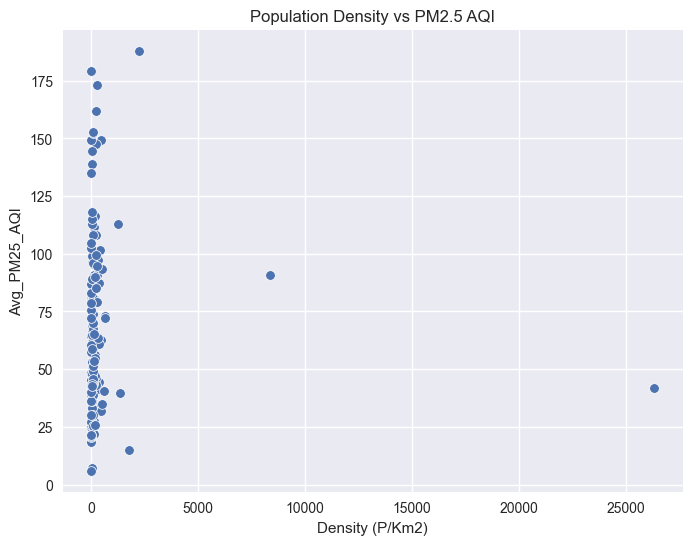

In [126]:
# Density vs Pollution

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged,
    x="Density (P/Km2)",
    y="Avg_PM25_AQI"
)

plt.title("Population Density vs PM2.5 AQI")
plt.show()


In [127]:
merged[["Density (P/Km2)", "Avg_PM25_AQI"]].corr()

,Density (P/Km2),Avg_PM25_AQI
Density (P/Km2),1.000000,-0.014517
Avg_PM25_AQI,-0.014517,1.000000


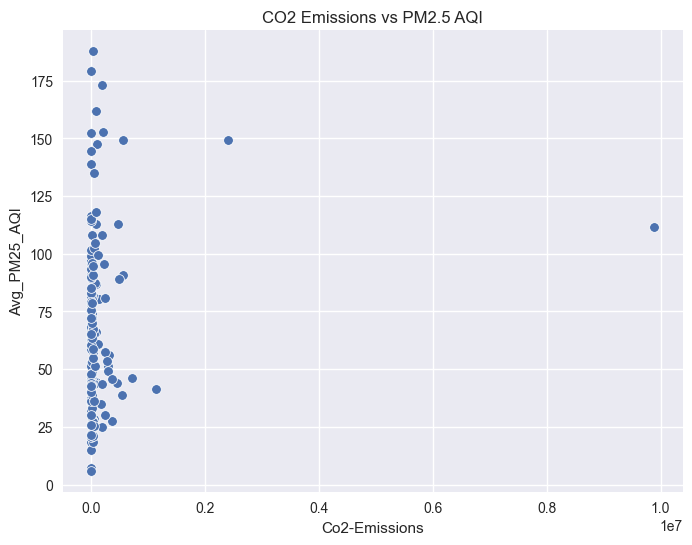

In [128]:
# CO2 vs PM2.5
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged,
    x="Co2-Emissions",
    y="Avg_PM25_AQI"
)

plt.title("CO2 Emissions vs PM2.5 AQI")
plt.show()

In [129]:
merged[["Co2-Emissions", "Avg_PM25_AQI"]].corr()

,Co2-Emissions,Avg_PM25_AQI
Co2-Emissions,1.000000,0.142957
Avg_PM25_AQI,0.142957,1.000000


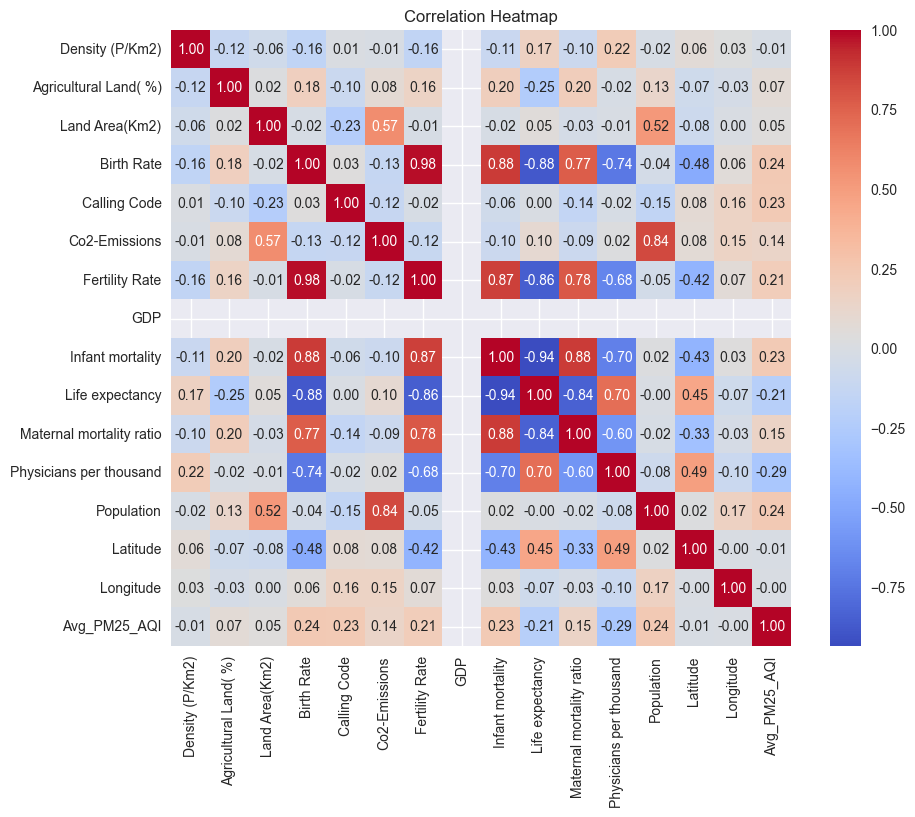

In [130]:
# Correlation Heatmap (All Variables)
plt.figure(figsize=(10,8))

sns.heatmap(
    merged.select_dtypes(include=["float64", "int64"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

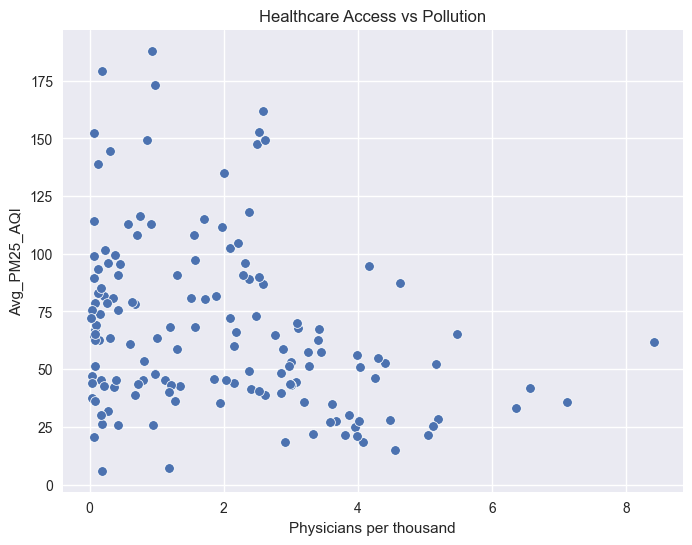

In [131]:
# Development vs Pollution Analysis
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged,
    x="Physicians per thousand",
    y="Avg_PM25_AQI"
)

plt.title("Healthcare Access vs Pollution")
plt.show()

In [132]:
merged[["Physicians per thousand", "Avg_PM25_AQI"]].corr()

,Physicians per thousand,Avg_PM25_AQI
Physicians per thousand,1.000000,-0.286664
Avg_PM25_AQI,-0.286664,1.000000


In [133]:
features = merged[
    [
        "Avg_PM25_AQI",
        "Physicians per thousand",
        "Infant mortality",
        "Life expectancy",
        "Co2-Emissions"
    ]
].dropna()

features.head()

,Avg_PM25_AQI,Physicians per thousand,Infant mortality,Life expectancy,Co2-Emissions
0,95.918367,0.28,47.9,64.5,8672.0
1,68.093750,1.20,7.8,78.5,4536.0
2,80.250000,1.72,20.1,76.7,150006.0
4,81.925926,0.21,51.6,60.8,34693.0
5,24.867647,3.96,8.8,76.5,201348.0


In [134]:
# Standardize Data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [135]:
# KMeans Clustering

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

features["Cluster"] = clusters
features.head()

,Avg_PM25_AQI,Physicians per thousand,Infant mortality,Life expectancy,Co2-Emissions,Cluster
0,95.918367,0.28,47.9,64.5,8672.0,0
1,68.093750,1.20,7.8,78.5,4536.0,1
2,80.250000,1.72,20.1,76.7,150006.0,1
4,81.925926,0.21,51.6,60.8,34693.0,0
5,24.867647,3.96,8.8,76.5,201348.0,1


In [136]:
# KMeans Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

features["Cluster"] = clusters
features.head()

,Avg_PM25_AQI,Physicians per thousand,Infant mortality,Life expectancy,Co2-Emissions,Cluster
0,95.918367,0.28,47.9,64.5,8672.0,0
1,68.093750,1.20,7.8,78.5,4536.0,1
2,80.250000,1.72,20.1,76.7,150006.0,1
4,81.925926,0.21,51.6,60.8,34693.0,0
5,24.867647,3.96,8.8,76.5,201348.0,1


In [137]:
features.groupby("Cluster").mean()

,Avg_PM25_AQI,Physicians per thousand,Infant mortality,Life expectancy,Co2-Emissions
Cluster,,,,,
0,79.201869,0.353448,42.884483,64.325862,8.259247e+04
1,60.337696,2.842967,8.147253,77.363736,1.066173e+05
2,111.703145,1.980000,7.400000,77.000000,9.893038e+06


In [164]:
cluster_map = {
    0: "High Risk (Low Health Infra)",
    1: "Developed & Low Pollution",
    2: "Industrial High Emission"
}

features["Cluster_Label"] = features["Cluster"].map(cluster_map)

In [165]:
features["Cluster_Label"].unique()

array(['High Risk (Low Health Infra)', 'Developed & Low Pollution',
       'Industrial High Emission'], dtype=object)

In [171]:
features.groupby("Cluster_Label").size()

Cluster_Label
Developed & Low Pollution       91
High Risk (Low Health Infra)    58
Industrial High Emission         1
dtype: int64

In [ ]:
# Pollution Risk Prediction Model.

# Create Target Variable

features["High_Pollution"] = (features["Avg_PM25_AQI"] > 80).astype(int)
features.head()

,Avg_PM25_AQI,Physicians per thousand,Infant mortality,Life expectancy,Co2-Emissions,Cluster,Cluster_Label,High_Pollution
0,95.918367,0.28,47.9,64.5,8672.0,0,High Risk (Low Health Infra),1
1,68.093750,1.20,7.8,78.5,4536.0,1,Developed & Low Pollution,0
2,80.250000,1.72,20.1,76.7,150006.0,1,Developed & Low Pollution,1
4,81.925926,0.21,51.6,60.8,34693.0,0,High Risk (Low Health Infra),1
5,24.867647,3.96,8.8,76.5,201348.0,1,Developed & Low Pollution,0


In [191]:
# Define Features and Target
X = features[
    [
        "Physicians per thousand",
        "Infant mortality",
        "Life expectancy",
        "Co2-Emissions"
    ]
]

y = features["High_Pollution"]

In [192]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [193]:
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [202]:
features["High_Pollution"].value_counts()

High_Pollution
0    96
1    54
Name: count, dtype: int64

In [212]:
# Evaluate Model
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6222222222222222
              precision    recall  f1-score   support

           0       0.71      0.69      0.70        29
           1       0.47      0.50      0.48        16

    accuracy                           0.62        45
   macro avg       0.59      0.59      0.59        45
weighted avg       0.63      0.62      0.62        45



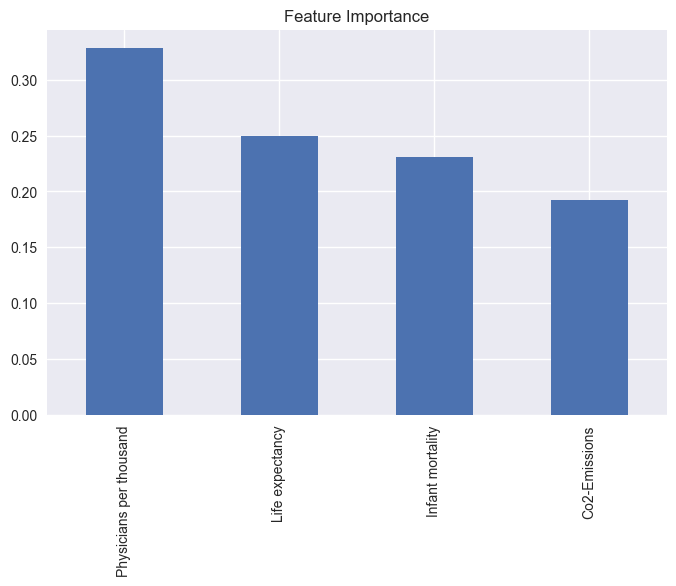

In [213]:
# Check Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

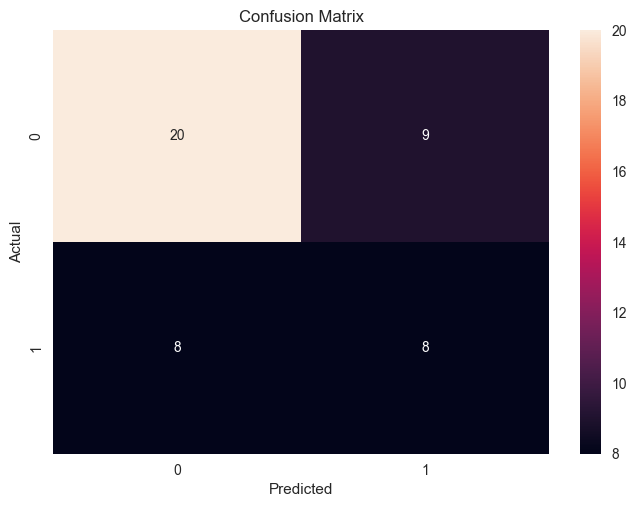

In [214]:
# Add Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [215]:
# Improve Model
# Add class balancing

model = RandomForestClassifier(class_weight="balanced", random_state=42)

In [216]:
# Urban Pollution Risk Prediction System

# Create Pollution Risk Target
features["High_Pollution"] = (features["Avg_PM25_AQI"] > 75).astype(int)

features["High_Pollution"].value_counts()

High_Pollution
0    96
1    54
Name: count, dtype: int64

In [217]:
# Define Features & Target
# We will NOT use Avg_PM25_AQI to predict itself.
X = features[[
    "Physicians per thousand",
    "Infant mortality",
    "Life expectancy",
    "Co2-Emissions"
]]

y = features["High_Pollution"]

In [221]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [224]:
model_bal = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

model_bal.fit(X_train, y_train)

y_pred_bal = model_bal.predict(X_test)

print("Balanced Accuracy:", accuracy_score(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

Balanced Accuracy: 0.6
              precision    recall  f1-score   support

           0       0.69      0.69      0.69        29
           1       0.44      0.44      0.44        16

    accuracy                           0.60        45
   macro avg       0.56      0.56      0.56        45
weighted avg       0.60      0.60      0.60        45



In [225]:
# Train Model (Balanced)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

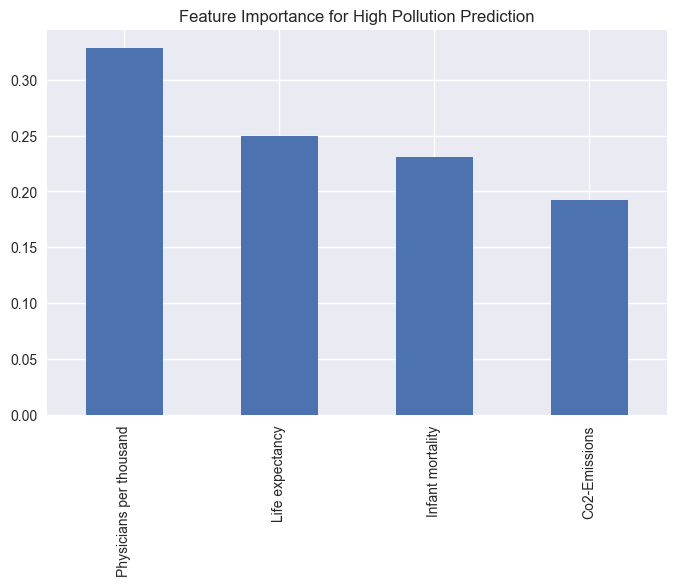

Physicians per thousand    0.328325
Life expectancy            0.249228
Infant mortality           0.230442
Co2-Emissions              0.192005
dtype: float64

In [226]:
importance = model.feature_importances_
feature_names = X.columns

import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.plot(kind="bar")
plt.title("Feature Importance for High Pollution Prediction")
plt.show()

feat_imp

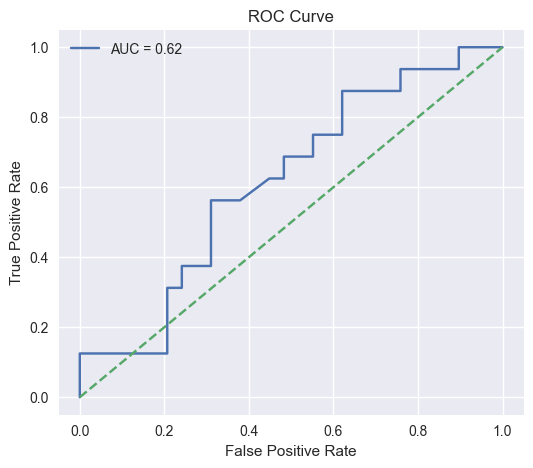

In [227]:
# ROC Curve to show model discrimination ability:

from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [228]:
# Add prediction & cluster back to merged
merged["High_Pollution"] = features["High_Pollution"]
merged["Cluster_Label"] = features["Cluster_Label"]

# Save final dataset
merged.to_csv("urban_environment_dashboard_data.csv", index=False)